In [1]:
#This notebook implements a DeepONet from scratch using FLAX

#importing all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.io

import jax
import jax.numpy as jnp
from jax import random
from jax import jit, vmap, pmap, grad, value_and_grad

from tqdm import tqdm

import flax
import flax.linen as nn
import optax

from typing import Callable, Tuple, List, Dict, Optional, Any, Sequence

from sklearn.model_selection import train_test_split

from functools import partial

import os
import sys
import pickle

In [2]:
jax.local_devices()

[cuda(id=0)]

In [3]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu


In [4]:
# seed = np.random.choice(np.arange(99999), size = 1)[0]
seed = 42
print("Seed: ", seed)
np.random.seed(seed)
key = random.PRNGKey(seed)

Seed:  42


2025-11-05 13:54:04.785182: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.4 which is older than the ptxas CUDA version (12.5.82). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [5]:
data = scipy.io.loadmat("Burger.mat")

#Reading the input and output data
inputs = jnp.array(data['input'])
outputs = jnp.array(data['output'])

#Only consider half of the data upto timestep = 51
outputs = outputs[:,:50,:]

ns, nt, nx = outputs.shape
print(f"ns = {ns}, nt = {nt}, nx = {nx}")

#Create the grid with coordinate pairs (t,x) to feed into trunk network
tspan = jnp.array(data['tspan'].reshape(-1))
xspan = jnp.linspace(0, 1, nx)

#Take only half of the temporal domain
tspan = tspan[:50]

[t,x] = jnp.meshgrid(tspan, xspan, indexing = 'ij')
grid = jnp.transpose(jnp.array([t.flatten(), x.flatten()]))
print(grid.shape)
print(grid)


# Split the data into training (2000) and testing (500) samples
inputs_train, inputs_test, outputs_train, outputs_test = train_test_split(inputs, outputs, test_size=500, random_state=seed)

outputs_train = outputs_train.reshape(outputs_train.shape[0], nt*nx)
outputs_test = outputs_test.reshape(outputs_test.shape[0], nt*nx)

# Check the shapes of the subsets
print("Shape of inputs_train:", inputs_train.shape)
print("Shape of inputs_test:", inputs_test.shape)
print("Shape of outputs_train:", outputs_train.shape)
print("Shape of outputs_test:", outputs_test.shape)

ns = 2500, nt = 50, nx = 101
(5050, 2)
[[0.         0.        ]
 [0.         0.01      ]
 [0.         0.02      ]
 ...
 [0.49       0.97999996]
 [0.49       0.98999995]
 [0.49       1.        ]]
Shape of inputs_train: (2000, 101)
Shape of inputs_test: (500, 101)
Shape of outputs_train: (2000, 5050)
Shape of outputs_test: (500, 5050)


In [6]:
#Network Inputs
branch_inputs_train = inputs_train    ##--- (2000,101)
trunk_inputs_train = grid             ##--- (10201,2)

#Inspecting the shapes
print("Shape of train branch inputs: ",branch_inputs_train.shape)
print("Shape of train trunk inputs: ",trunk_inputs_train.shape)
print("Shape of train output: ",outputs_train.shape)

Shape of train branch inputs:  (2000, 101)
Shape of train trunk inputs:  (5050, 2)
Shape of train output:  (2000, 5050)


In [7]:
branch_inputs_test = inputs_test      ##--- (500, 101)
trunk_inputs_test = grid              ##--- (10201,2)

#Inspecting the shapes
print("Shape of test branch inputs: ",branch_inputs_test.shape)
print("Shape of test trunk inputs: ",trunk_inputs_test.shape)
print("Shape of test output: ",outputs_test.shape)

Shape of test branch inputs:  (500, 101)
Shape of test trunk inputs:  (5050, 2)
Shape of test output:  (500, 5050)


In [8]:
class branch_net(nn.Module):

    layer_sizes: Sequence[int] 
    activation: Callable

    def setup(self):
        self.dense_layers = [nn.Dense(size) for size in self.layer_sizes]

    def __call__(self,x):
        for layer in self.dense_layers[:-1]:
            x = layer(x)
            x = self.activation(x)
        x = self.dense_layers[-1](x)
        return x

In [9]:
class trunk_net(nn.Module):

    layer_sizes: Sequence[int]    
    activation: Callable

    def setup(self):
        self.dense_layers = [nn.Dense(size) for size in self.layer_sizes]

    def __call__(self,x):
        for layer in self.dense_layers:
            x = layer(x)
            x = self.activation(x)
        return x

In [10]:
class DeepONet(nn.Module):

    branch_net_config: Sequence[int]
    trunk_net_config: Sequence[int]

    def setup(self):

        self.branch_net = branch_net(self.branch_net_config, nn.activation.tanh)
        self.trunk_net = trunk_net(self.trunk_net_config, nn.activation.tanh)


    def __call__(self, x_branch, x_trunk):
        
        #Vectorize over multiple samples of input functions
        branch_outputs = vmap(self.branch_net, in_axes = 0)(x_branch)
        
        #Vectorize over multiple query points
        trunk_outputs = vmap(self.trunk_net, in_axes = 0)(x_trunk)
        
        inner_product = jnp.einsum('ik,jk->ij', branch_outputs, trunk_outputs)

        return inner_product

In [11]:
num_sensor_locations = branch_inputs_train.shape[1]
num_query_locations = 2
latent_vector_size = 60

branch_network_layer_sizes = [128]*6 + [latent_vector_size]
trunk_network_layer_sizes = [128]*6 + [latent_vector_size]

model = DeepONet(branch_net_config = branch_network_layer_sizes, 
                                      trunk_net_config = trunk_network_layer_sizes)

In [12]:
model

DeepONet(
    # attributes
    branch_net_config = [128, 128, 128, 128, 128, 128, 60]
    trunk_net_config = [128, 128, 128, 128, 128, 128, 60]
)

In [13]:
# Check if it's a valid Flax model
print(isinstance(model, nn.Module))  # Should return True if it's a valid Flax model

True


In [14]:
def save_model_params(params, path, filename):
    
    #Create output directory for saving model params
    if not os.path.exists(path):
        os.makedirs(path)
    
    save_path = os.path.join(path, filename)
    with open(save_path, 'wb') as f:
        pickle.dump(params, f)

def load_model_params(path, filename):
    load_path = os.path.join(path, filename)
    with open(load_path, 'rb') as f:
        params = pickle.load(f)
    return params

In [15]:
# Define the training process from here
@jax.jit
def loss_fn(params, branch_inputs, trunk_inputs, gt_outputs):
    predictions = model.apply(params, branch_inputs,trunk_inputs)
    mse_loss = jnp.mean(jnp.square(predictions - gt_outputs))
    return mse_loss

@jax.jit
def update(params, branch_inputs, trunk_inputs, gt_outputs, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, branch_inputs, trunk_inputs, gt_outputs)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# Initialize model parameters
# key = random.PRNGKey(42)
params = model.init(key, branch_inputs_train, trunk_inputs_train)

# # Optimizer setup
lr_scheduler = optax.schedules.exponential_decay(init_value=1e-3, transition_steps=5000, decay_rate=0.95)
optimizer = optax.adam(learning_rate=lr_scheduler)
opt_state = optimizer.init(params)

training_loss_history = []
test_loss_history = []
num_epochs = int(2e5)
batch_size = 256

min_test_loss = jnp.inf

filepath = 'DeepONet_full_rollout'

In [ ]:
for epoch in tqdm(range(num_epochs), desc="Training Progress"):

    #Perform mini-batching
    shuffled_indices = jax.random.permutation(random.PRNGKey(epoch), branch_inputs_train.shape[0])
    batch_indices = shuffled_indices[:batch_size]

    branch_inputs_train_batch = branch_inputs_train[batch_indices]
    outputs_train_batch = outputs_train[batch_indices]

    # Update the parameters and optimizer state
    params, opt_state, loss = update(
        params=params,
        branch_inputs=branch_inputs_train_batch,
        trunk_inputs=trunk_inputs_train,
        gt_outputs=outputs_train_batch,
        opt_state=opt_state
    )

    training_loss_history.append(loss)
    
    #Do predictions on the test data simultaneously
    test_mse_loss = loss_fn(params = params, 
                            branch_inputs = branch_inputs_test, 
                            trunk_inputs = trunk_inputs_test, 
                            gt_outputs = outputs_test)
    test_loss_history.append(test_mse_loss)
    
    #Save the params of the best model encountered till now
    if test_mse_loss < min_test_loss:
        best_params = params
        # save_model_params(params, path = filepath, filename = 'model_params_best.pkl')
        min_test_loss = test_mse_loss
    
    #Print the train and test loss history every 1000 epochs
    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, training_loss_MSE: {loss}, test_loss_MSE: {test_mse_loss}, \
              best_test_loss_MSE: {min_test_loss}")

In [ ]:
# plt.figure(dpi = 130)
# plt.semilogy(np.arange(num_epochs), training_loss_history, label = "Train loss")
# plt.semilogy(np.arange(num_epochs), test_loss_history, label = "Test loss")

# plt.xlabel("Epochs")
# plt.ylabel("Loss")

# plt.tick_params(which = 'major', axis = 'both', direction = 'in', length = 6)
# plt.tick_params(which = 'minor', axis = 'both', direction = 'in', length = 3.5)
# plt.minorticks_on()

# plt.grid(alpha = 0.3)
# plt.legend(loc = 'best')

# save = False
# if save:
#     plt.savefig(filepath + "\loss.jpeg", dpi = 500)
# plt.show()

In [16]:
#Save loss arrays
save = False
if save:
    np.save(filepath + "/train_loss.npy", training_loss_history)
    np.save(filepath + "/test_loss.npy", test_loss_history)

Test error mse: 1.0632636076479685e-05


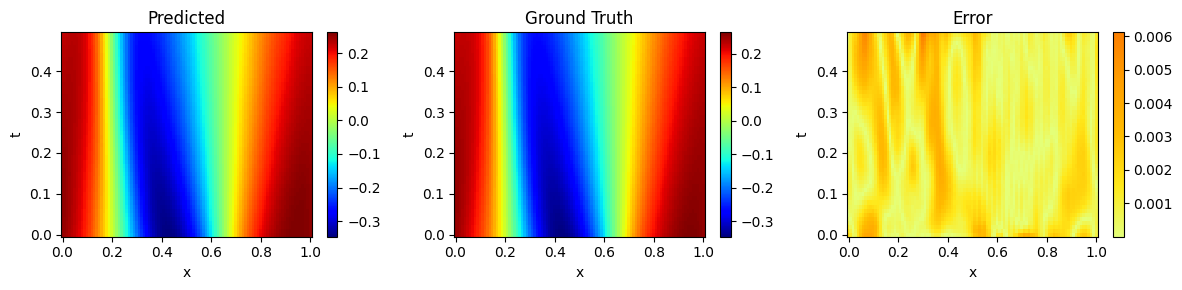

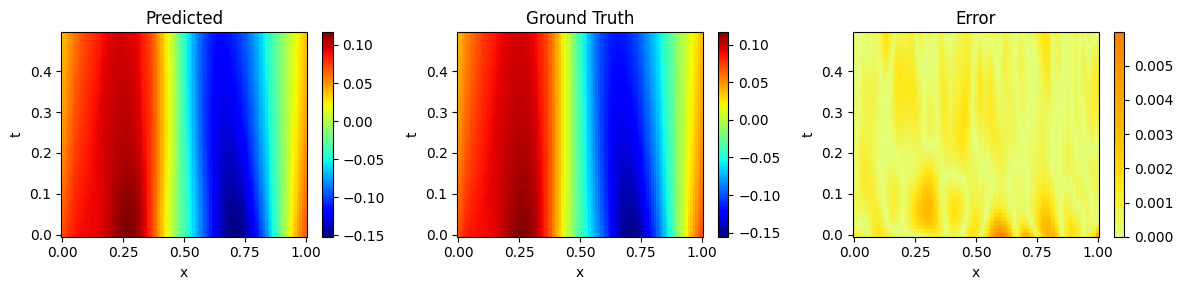

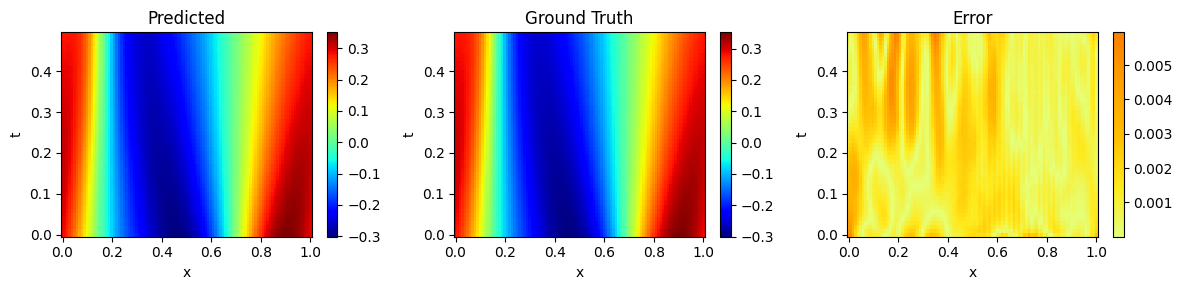

In [17]:
# Predictions
import sklearn
from sklearn import metrics
filepath = 'DeepONet_full_rollout'
#Import the best model saved after full training
best_params = load_model_params(path = filepath, filename = 'model_params_best.pkl')

#Access best params from within the code


predictions_outputs_test = model.apply(best_params, branch_inputs_test, trunk_inputs_test)
test_error_mse = metrics.mean_squared_error(predictions_outputs_test, outputs_test)
print(f"Test error mse: {test_error_mse}")

#Randomly selecting "size" number of samples out of the test dataset
random_samples = np.random.choice(np.arange(outputs_test.shape[0]), size = 3, replace = 'True')

for i in random_samples:
    
    prediction_i = predictions_outputs_test[i]
    prediction_i = prediction_i.reshape(nt,nx)
    target_i = outputs_test[i]
    target_i = target_i.reshape(nt,nx)
    
    error_i = np.abs(prediction_i - target_i)
    
    plt.figure(figsize = (12,3))
    
    # plt.subplot(1,4,1)
    # plt.plot(xspan, inputs_test[i])
    # plt.xlabel("x")
    # plt.ylabel("s(t=0,x)")
    # plt.title("Initial condition")
    
    plt.subplot(1,3,1)
    plt.pcolor(x, t, prediction_i, cmap = 'jet')
    plt.colorbar()
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title("Predicted")
    
    plt.subplot(1,3,2)
    plt.pcolor(x, t, target_i, cmap = 'jet')
    plt.colorbar()
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title("Ground Truth")
  
    
    plt.subplot(1,3,3)
    plt.pcolor(x, t, error_i, cmap = 'Wistia')
    plt.colorbar()
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title("Error")
    
    
    plt.tight_layout()
    plt.show()

(10201, 2)
[[0.         0.        ]
 [0.         0.01      ]
 [0.         0.02      ]
 ...
 [1.         0.97999996]
 [1.         0.98999995]
 [1.         1.        ]]
Total inferencing time for 2500 samples: 0.4026346206665039
(2500, 10201) (10201, 2)


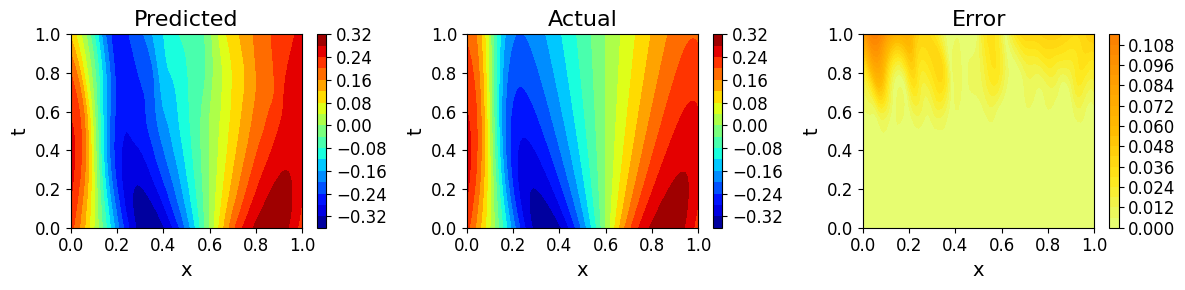

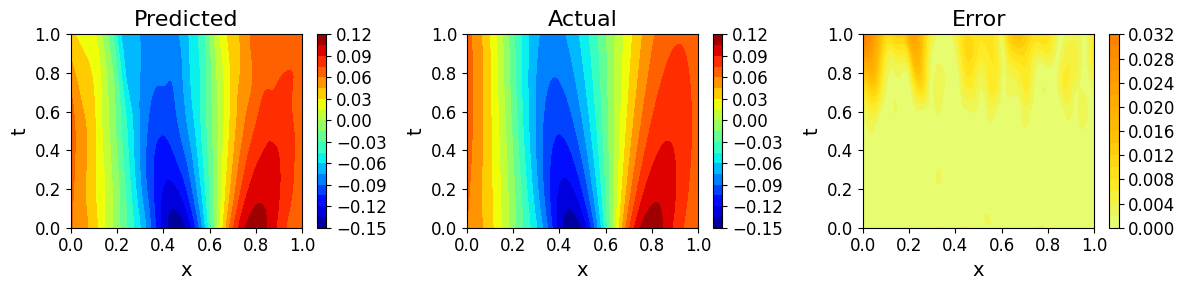

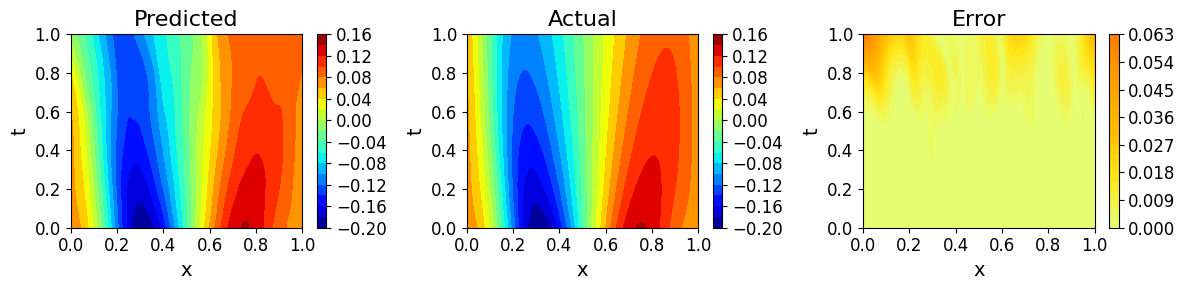

In [18]:
# Predictions
import sklearn
from sklearn import metrics
import time

filepath = 'DeepONet_full_rollout'
#Import the best model saved after full training
best_params = load_model_params(path = filepath, filename = 'model_params_best.pkl')

#Use best params from within the code

outputs = jnp.array(data['output'])

branch_input_new = outputs[:, 0,:]
tspan = jnp.linspace(0, 1, 101)
xspan = jnp.linspace(0, 1, 101)

[t_new, x_new] = jnp.meshgrid(tspan, xspan, indexing = 'ij')
grid = jnp.transpose(jnp.array([t_new.flatten(), x_new.flatten()]))
print(grid.shape)
print(grid)

start_time = time.time()
predictions_outputs_new = model.apply(best_params, branch_input_new, grid)
end_time = time.time()
print(f"Total inferencing time for {predictions_outputs_new.shape[0]} samples: {end_time-start_time}")

print(predictions_outputs_new.shape, grid.shape)

predictions_outputs_new = predictions_outputs_new.reshape(predictions_outputs_new.shape[0], 101, 101)

# test_error_mse = metrics.mean_squared_error(predictions_outputs_new, outputs)
# print(f"Test error mse: {test_error_mse}")

#Randomly selecting "size" number of samples out of the test dataset
# random_samples = np.random.choice(np.arange(outputs.shape[0]), size = 3, replace = 'True')

random_samples = [70, 140, 320]

for i in random_samples:
    
    prediction_i = predictions_outputs_new[i, :, :]
    # prediction_i = prediction_i.reshape(101, 101)
    target_i = outputs[i, :, :]
    # target_i = target_i.reshape(101, 101)
    
    error_i = np.abs(prediction_i - target_i)
    
    plt.figure(figsize = (12,3))
    
    plt.subplot(1,3,1)
    contour1 = plt.contourf(xspan, tspan, prediction_i, levels = 20, cmap = 'jet')
    cbar1 = plt.colorbar()
    cbar1.ax.tick_params(labelsize = 12)
    plt.xlabel("x", fontsize = 14)
    plt.ylabel("t", fontsize = 14)
    plt.xticks(fontsize = 12)
    plt.yticks(fontsize = 12)
    plt.title("Predicted", fontsize = 16)
    
    plt.subplot(1,3,2)
    contour2 = plt.contourf(xspan, tspan, target_i, levels = 20, cmap = 'jet')
    cbar2 = plt.colorbar()
    cbar2.ax.tick_params(labelsize = 12)
    plt.xlabel("x", fontsize = 14)
    plt.ylabel("t", fontsize = 14)
    plt.xticks(fontsize = 12)
    plt.yticks(fontsize = 12)
    plt.title("Actual", fontsize = 16)
  
    
    plt.subplot(1,3,3)
    contour3 = plt.contourf(xspan, tspan, error_i, levels = 20, cmap = 'Wistia')
    cbar3 = plt.colorbar()
    cbar3.ax.tick_params(labelsize = 12)
    plt.xlabel("x", fontsize = 14)
    plt.ylabel("t", fontsize = 14)
    plt.xticks(fontsize = 12)
    plt.yticks(fontsize = 12)
    plt.title("Error", fontsize = 16)
    
    
    plt.tight_layout()
    # plt.savefig(filepath + f"/Contour_plots_{i}.jpeg", dpi = 800)
    plt.show()


In [19]:
jnp.linalg.norm(predictions_outputs_new - outputs)/jnp.linalg.norm(outputs)

Array(0.09210833, dtype=float32)

In [20]:
predictions_outputs_new.shape, outputs.shape

((2500, 101, 101), (2500, 101, 101))

In [21]:
auto_reg_error = []
num_time_steps = 101

for i in range(num_time_steps):
    l2_error = jnp.linalg.norm(predictions_outputs_new[:,i,:] - outputs[:,i,:])/jnp.linalg.norm(outputs[:,i,:])
    auto_reg_error.append(l2_error)

In [22]:
len(auto_reg_error)

101

In [23]:
#Compute statistics

t = [60, 70, 90, 100]
for t_idx in t:
    print(f"T_idx: {t_idx}, L2 error: {auto_reg_error[t_idx]}")

T_idx: 60, L2 error: 0.0433124378323555
T_idx: 70, L2 error: 0.0965394526720047
T_idx: 90, L2 error: 0.24131529033184052
T_idx: 100, L2 error: 0.32808879017829895


In [24]:
#Save the auto_reg_error array for comparing with NODE approach
save = False
if save:
    np.save(filepath + "/Auto_reg_error_full_rollout.npy", auto_reg_error)

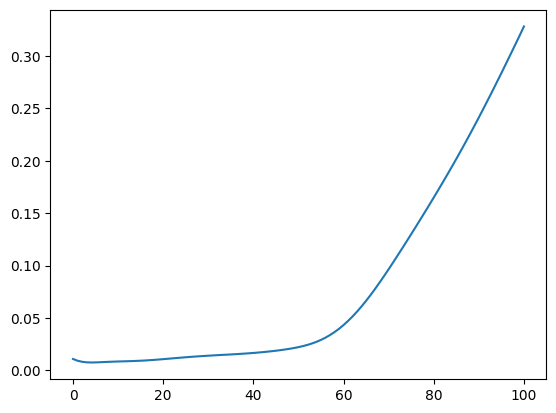

In [25]:
plt.plot(auto_reg_error)
plt.show()

In [26]:
#Save the prediction array
save=True
if save:
    np.save("DeepONet_full_rollout/u_pred.npy", predictions_outputs_new)

In [ ]:
# Get the representative sample plots for u(x, t= 0.25), u(x, t=0.5), u(x, t=0.75), u(x, t= 1.0)

sample_idx = 70
time_steps_idx = [25, 50, 70, 90, 100]

u_pred = predictions_outputs_new
output = outputs
plt.figure(figsize=(12, 2.75))  # wider figure for 1x4 layout

for idx, i in enumerate(time_steps_idx):
    plt.subplot(1, 5, idx + 1)
    plt.plot(np.linspace(0, 1, 101), u_pred[sample_idx, i, :], label="Predicted",
             color="red", marker='o', markersize=1, linestyle='--')
    plt.plot(np.linspace(0, 1, 101), output[sample_idx, i, :], label="Actual",
             color="blue", marker='o', markersize=1, linestyle='-')
    # plt.xlabel("x", fontsize=14)
    # plt.title(f"t = {i * 0.01:.2f}", fontsize=14)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.ylim(-0.65, 0.65)
    
    plt.gca().set_xticklabels([])

    plt.tick_params(axis="both", which="major", length=6, direction="in")
    plt.tick_params(axis="both", which="minor", length=3.5, direction="in")
    plt.minorticks_on()

    plt.grid(which="major", axis="both", alpha=0.6, linestyle='-')
    plt.grid(which="minor", axis="both", alpha=0.3, linestyle='--')

    if idx == 0:  # Only add the y-axis label and legend to the first subplot
        plt.ylabel("u(x, t)", fontsize=14)
        # plt.legend(fontsize=12)
    else:
        plt.gca().set_yticklabels([])

plt.tight_layout()
# plt.savefig(filepath + "/Burgers_u_xt_subplot.jpeg", dpi=800)
plt.show()